# Stage 29 — Warm-Start L3+L4 (Exp A)

**Hypothesis (RQ10):** The Stage 1 (seed=42) encoder already contains good L3/L4
representations — proven by L2+L3+L4 warmstart Dice=0.8635 in v6-D. If we warm-start
a fresh M2(L3+L4) using this encoder but **exclude L2 entirely**, the decoder will
co-adapt to L3+L4 skips only, eliminating the L2 dominance problem.

**Key difference from v6-D:** `PROTO_LEVELS=[3,4]` (not [2,4] or [2,3,4]).  
Encoder warm-start identical; only the level set changes.

**Notebook contains:** training → 3D Dice eval → proto quality → effective quality → RQ10 verdict.

## 0. Config

In [ ]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

# ── Stage 1: existing checkpoint (already trained in v6) ─────────────────────
STAGE1_CKPT = "checkpoints/proto_seg_ct_l1234_attn_noent_ep40.pth"
STAGE1_ATTN_LOG = "results/v6/attn_evolution_l1234_noent_stage1.csv"
S1_PROTO_LEVELS = [1, 2, 3, 4]

# ── Stage 2: Warm-start L3+L4 ────────────────────────────────────────────────
PROTO_LEVELS = [3, 4]  # ← L3+L4 only (key difference from v6-D)
USE_LEVEL_ATTENTION = False
MODALITY = "ct"
SUFFIX = "_l3l4_warmstart_v7"
FREEZE_ENCODER_PHASE_A = False

# ── Training hyperparameters (identical to cold-start M2) ────────────────────
LAMBDA_DIV = 0.001
LAMBDA_PUSH = 0.5
LAMBDA_PULL = 0.25
BATCH_SIZE = 16
LR = 3e-4
WEIGHT_DECAY = 1e-5
PHASE_A_END = 20
PHASE_B_END = 80
PHASE_C_END = 100
VAL_EVERY = 5
PATIENCE = 15
PROJ_INTERVAL = 10

DATA_DIR = "data/pack/processed_data"
CKPT_DIR = "checkpoints"
LOG_DIR = "results/v7"

import pathlib

pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

CKPT_PATH = f"{CKPT_DIR}/proto_seg_{MODALITY}{SUFFIX}.pth"
PROJ_PATH = f"{CKPT_DIR}/projected_prototypes_{MODALITY}{SUFFIX}.pt"
LOG_PATH = f"{LOG_DIR}/train_curve_proto_{MODALITY}{SUFFIX}.csv"

print(f"Stage 1 ckpt : {STAGE1_CKPT}")
print(f"Stage 2      : PROTO_LEVELS={PROTO_LEVELS}  (L3+L4 only — no L2)")
print(f"Output ckpt  : {CKPT_PATH}")
print(f"Log          : {LOG_PATH}")

Stage 1 ckpt : checkpoints/proto_seg_ct_l1234_attn_noent_ep40.pth
Stage 2      : PROTO_LEVELS=[3, 4]  (L3+L4 only — no L2)
Output ckpt  : checkpoints/proto_seg_ct_l3l4_warmstart_v7.pth
Log          : results/v7/train_curve_proto_ct_l3l4_warmstart_v7.csv


## 1. Imports & Device

In [ ]:
import csv, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset,
    MMWHSPatientDataset,
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
)
from src.models.proto_seg_net import ProtoSegNet
from src.models.prototype_layer import PrototypeProjection
from src.losses.segmentation import SegmentationLoss, compute_class_weights
from src.losses.diversity_loss import ProtoSegLoss
from src.metrics.dice import dice_per_class, mean_foreground_dice
from src.metrics.proto_quality import (
    compute_purity,
    compute_compactness,
    compute_per_level_ap,
    compute_level_dominance,
    compute_effective_quality,
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]
print(f"Device: {DEVICE}")

Device: mps


## 2. Data & Class Weights

In [ ]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(
    f"Train: {len(loaders['train'].dataset)}  "
    f"Val: {len(loaders['val'].dataset)}  "
    f"Test: {len(loaders['test'].dataset)}"
)

class_weights = torch.load(f"data/class_weights_{MODALITY}.pt", weights_only=True)
print(f"Class weights: {class_weights.numpy().round(3)}")

Train: 3389  Val: 382  Test: 484
Class weights: [0.021 0.819 1.197 1.066 1.192 0.795 1.486 1.423]


## 3. Load Stage 1 Encoder → Init Warm-Start M2(L3+L4)

Stage 1 checkpoint: `proto_seg_ct_l1234_attn_noent_ep40.pth` (trained in v6, seed=42, ep 45).  
Known attention at stop: w_L4=0.63, w_L2=0.30 (L2 feedback loop active).  
We transfer encoder weights only — decoder and prototype layers are randomly initialised.  
**Crucially:** `PROTO_LEVELS=[3,4]` means the decoder only receives L3 and L4 skip connections.

In [ ]:
src_ckpt = torch.load(STAGE1_CKPT, map_location="cpu", weights_only=False)
print(
    f"Stage 1 checkpoint: epoch {src_ckpt['epoch']}, best_val {src_ckpt['best_val_dice']:.4f}"
)

# Report attention at stop
attn_log = pd.read_csv(STAGE1_ATTN_LOG)
r = attn_log.iloc[-1]
print(f"\nAttention at ep {int(r['epoch'])}:")
for l in S1_PROTO_LEVELS:
    print(f"  w_L{l} = {r[f'w_L{l}']:.4f}")
w_low = r["w_L1"] + r["w_L2"]
print(
    f"\nw_L1+L2 = {w_low:.4f}  (L2 feedback loop: {'active' if w_low > 0.05 else 'suppressed'})"
)
print(f"→ We ignore Stage 1 discovery and use L3+L4 directly.")

# Init fresh M2(L3+L4)
model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=PROTO_LEVELS,
    use_level_attention=USE_LEVEL_ATTENTION,
).to(DEVICE)

# Transfer encoder weights
src_state = src_ckpt["model_state_dict"]
own_state = model.state_dict()
transferred, skipped = [], []
for k, v in src_state.items():
    if k.startswith("encoder.") and k in own_state and own_state[k].shape == v.shape:
        own_state[k].copy_(v)
        transferred.append(k)
    else:
        skipped.append(k)
model.load_state_dict(own_state)

print(f"\nTransferred : {len(transferred)} encoder tensors")
print(f"Skipped     : {len(skipped)} (proto_layers, decoder, attention — random init)")
print(
    f"Model       : proto_levels={model.proto_levels}  use_attn={model.use_level_attention}"
)
print(f"Total params: {model.count_parameters()['total']:,}")

# Sanity: encoder differs from random init
fresh = ProtoSegNet(n_classes=NUM_CLASSES, proto_levels=PROTO_LEVELS).to("cpu")
src_p = next(p for n, p in model.named_parameters() if "encoder" in n)
fresh_p = next(p for n, p in fresh.named_parameters() if "encoder" in n)
diff = (src_p.cpu() - fresh_p).abs().mean().item()
print(f"\nEncoder diff vs random init: {diff:.4f}  (> 0 confirms warm-start active)")

Stage 1 checkpoint: epoch 45, best_val 0.7952

Attention at ep 45:
  w_L1 = 0.0069
  w_L2 = 0.2979
  w_L3 = 0.0629
  w_L4 = 0.6323

w_L1+L2 = 0.3048  (L2 feedback loop: active)
→ We ignore Stage 1 discovery and use L3+L4 directly.

Transferred : 72 encoder tensors
Skipped     : 34 (proto_layers, decoder, attention — random init)
Model       : proto_levels=[3, 4]  use_attn=False
Total params: 2,553,704

Encoder diff vs random init: 0.2145  (> 0 confirms warm-start active)


## 4. Loss & Helpers

In [ ]:
seg_loss = SegmentationLoss(
    class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES
)
criterion = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch["image"].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch["label"])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


def run_projection(model, save_path):
    print("  [Proj] Building feature bank on CPU…", flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(
        DATA_DIR, MODALITY, "train", augment=False, preload=True
    )
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b["image"], b["label"]) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=model.proto_layers_dict(),
        device="cpu",
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt["proto_state"].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f"  [Proj] Done in {time.time() - t0:.1f}s", flush=True)


def set_phase(model, epoch, optimizer):
    if epoch <= PHASE_A_END:
        model.unfreeze_all()
        model.freeze_prototypes()
        if FREEZE_ENCODER_PHASE_A:
            for p in model.encoder.parameters():
                p.requires_grad_(False)
        phase = "A"
    elif epoch <= PHASE_B_END:
        model.unfreeze_all()
        phase = "B"
    else:
        model.freeze_encoder_and_prototypes()
        phase = "C"
    optimizer.param_groups[0]["params"] = [
        p for p in model.parameters() if p.requires_grad
    ]
    return phase


def save_checkpoint(epoch, model, best_val_dice):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_val_dice": best_val_dice,
            "proto_levels": model.proto_levels,
            "use_level_attention": model.use_level_attention,
            "class_weights": class_weights,
            "lambda_div": LAMBDA_DIV,
            "lambda_push": LAMBDA_PUSH,
            "lambda_pull": LAMBDA_PULL,
            "source_checkpoint": STAGE1_CKPT,
            "single_scale": model.single_scale,
            "no_soft_mask": model.no_soft_mask,
            "hard_mask": model.hard_mask,
            "mask_quantile": model.mask_quantile,
            "hard_mask_active": model.hard_mask_active,
        },
        CKPT_PATH,
    )


print("Helpers ready.")

Helpers ready.


## 5. Training Loop (3-Phase)

Identical protocol to cold-start M2.  
Phase A (1–20): encoder + decoder train, prototypes frozen.  
Phase B (21–80): all parameters, periodic prototype projection.  
Phase C (81–100): decoder only fine-tunes.

In [6]:
model.freeze_prototypes()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE_C_END)

fieldnames = [
    "epoch",
    "phase",
    "train_loss",
    "train_dice_loss",
    "train_ce_loss",
    "train_div_loss",
    "train_push_loss",
    "train_pull_loss",
    "val_mean_fg_dice",
    "lr",
    "epoch_time_s",
] + [f"val_dice_{LABEL_NAMES[c]}" for c in range(1, NUM_CLASSES)]
csv_file = open(LOG_PATH, "w", newline="")
writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

best_val_dice, best_epoch, no_improve = 0.0, 0, 0
current_phase = "A"

print(
    f"Warm-start M2  proto_levels={PROTO_LEVELS}  encoder from Stage 1 ep {src_ckpt['epoch']}"
)
print(f"λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}")
print(f"freeze_enc_phA={FREEZE_ENCODER_PHASE_A}  total_epochs={PHASE_C_END}\n")

for epoch in range(1, PHASE_C_END + 1):
    new_phase = set_phase(model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == "B":
            print(f"\n→ Phase B: all params (ep {PHASE_A_END + 1}–{PHASE_B_END})")
            best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == "C":
            print(f"\n→ Phase C: decoder only (ep {PHASE_B_END + 1}–{PHASE_C_END})")

    if (
        current_phase == "B"
        and epoch > PHASE_A_END + 1
        and (epoch - PHASE_A_END) % PROJ_INTERVAL == 0
    ):
        run_projection(model, PROJ_PATH)

    t0 = time.time()
    model.train()
    totals = dict(loss=0, dice_loss=0, ce_loss=0, div_loss=0, push_loss=0, pull_loss=0)
    n_batches = 0

    for batch in loaders["train"]:
        imgs = batch["image"].to(DEVICE)
        lbls = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        logits, hm = model(imgs)
        if current_phase == "A":
            out = seg_loss(logits, lbls)
            out["div_loss"] = out["push_loss"] = out["pull_loss"] = torch.zeros(
                1, device=DEVICE
            )
        else:
            out = criterion(logits, lbls, hm)
        out["loss"].backward()
        optimizer.step()
        for k in totals:
            v = out.get(k, torch.tensor(0.0))
            totals[k] += v.item() if hasattr(v, "item") else float(v)
        n_batches += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avgs = {k: v / n_batches for k, v in totals.items()}

    val_dice_dict = None
    val_mean = float("nan")
    if epoch % VAL_EVERY == 0 or epoch == PHASE_C_END:
        val_dice_dict = validate(model, loaders["val"])
        val_mean = mean_foreground_dice(val_dice_dict)
        improved = val_mean > best_val_dice
        if improved:
            best_val_dice = val_mean
            best_epoch = epoch
            no_improve = 0
            save_checkpoint(epoch, model, best_val_dice)
        else:
            no_improve += VAL_EVERY
        mark = " ← best" if improved else ""
        print(
            f"  [{current_phase}] Ep {epoch:3d}/{PHASE_C_END} | "
            f"loss={avgs['loss']:.4f} "
            f"(D={avgs['dice_loss']:.4f} CE={avgs['ce_loss']:.4f} "
            f"div={avgs['div_loss']:.4f} push={avgs['push_loss']:.4f} pull={avgs['pull_loss']:.4f}) | "
            f"val={val_mean:.4f}{mark} | "
            f"lr={scheduler.get_last_lr()[0]:.2e} | {epoch_time:.1f}s",
            flush=True,
        )

    row = {
        "epoch": epoch,
        "phase": current_phase,
        "train_loss": avgs["loss"],
        "train_dice_loss": avgs["dice_loss"],
        "train_ce_loss": avgs["ce_loss"],
        "train_div_loss": avgs["div_loss"],
        "train_push_loss": avgs["push_loss"],
        "train_pull_loss": avgs["pull_loss"],
        "val_mean_fg_dice": val_mean if val_dice_dict else None,
        "lr": scheduler.get_last_lr()[0],
        "epoch_time_s": epoch_time,
    }
    if val_dice_dict:
        for c in range(1, NUM_CLASSES):
            row[f"val_dice_{LABEL_NAMES[c]}"] = val_dice_dict.get(
                LABEL_NAMES[c], float("nan")
            )
    writer.writerow(row)
    csv_file.flush()

csv_file.close()
print(f"\nBest val Dice : {best_val_dice:.4f} at epoch {best_epoch}")
print(f"Checkpoint    : {CKPT_PATH}")

Warm-start M2  proto_levels=[3, 4]  encoder from Stage 1 ep 45
λ_div=0.001  λ_push=0.5  λ_pull=0.25
freeze_enc_phA=False  total_epochs=100

  [A] Ep   5/100 | loss=0.1310 (D=0.1501 CE=0.1120 div=0.0000 push=0.0000 pull=0.0000) | val=0.7518 ← best | lr=2.98e-04 | 27.7s
  [A] Ep  10/100 | loss=0.0795 (D=0.0898 CE=0.0691 div=0.0000 push=0.0000 pull=0.0000) | val=0.8153 ← best | lr=2.93e-04 | 28.5s
  [A] Ep  15/100 | loss=0.0722 (D=0.0805 CE=0.0639 div=0.0000 push=0.0000 pull=0.0000) | val=0.8056 | lr=2.84e-04 | 27.6s
  [A] Ep  20/100 | loss=0.0591 (D=0.0668 CE=0.0514 div=0.0000 push=0.0000 pull=0.0000) | val=0.8125 | lr=2.71e-04 | 27.6s

→ Phase B: all params (ep 21–80)
  [B] Ep  25/100 | loss=0.8254 (D=0.1168 CE=0.1020 div=855.3471 push=-0.4984 pull=0.4395) | val=0.7735 ← best | lr=2.56e-04 | 32.3s
  [Proj] Building feature bank on CPU…
Projected prototypes saved → checkpoints/projected_prototypes_ct_l3l4_warmstart_v7.pt
  [Proj] Done in 63.4s
  [B] Ep  30/100 | loss=0.5467 (D=0.1181 CE=

## 6. Training Curves

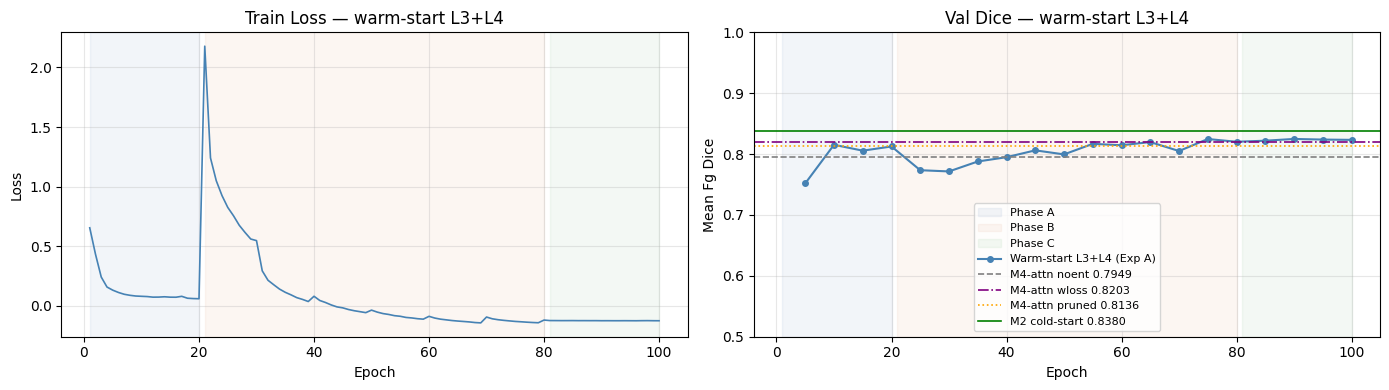

Best val Dice: 0.8249 at epoch 90


In [7]:
log = pd.read_csv(LOG_PATH)
val = log.dropna(subset=["val_mean_fg_dice"])

BASELINES_VAL = {
    "M4-attn noent": 0.7949,
    "M4-attn wloss": 0.8203,
    "M4-attn pruned": 0.8136,
    "M2 cold-start": 0.8380,
}
PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax in axes:
    for ph, color in PHASE_COLORS.items():
        mask = log["phase"] == ph
        if mask.any():
            ax.axvspan(
                log.loc[mask, "epoch"].min(),
                log.loc[mask, "epoch"].max(),
                alpha=0.07,
                color=color,
                label=f"Phase {ph}",
            )

axes[0].plot(log["epoch"], log["train_loss"], lw=1.2, color="steelblue")
axes[0].set(title="Train Loss — warm-start L3+L4", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(
    val["epoch"],
    val["val_mean_fg_dice"],
    "o-",
    ms=4,
    lw=1.5,
    color="steelblue",
    label="Warm-start L3+L4 (Exp A)",
)
bl_styles = ["--", "-.", ":", "-"]
bl_colors = ["gray", "purple", "orange", "green"]
for (bname, bval), ls, bc in zip(BASELINES_VAL.items(), bl_styles, bl_colors):
    axes[1].axhline(bval, ls=ls, lw=1.2, color=bc, label=f"{bname} {bval:.4f}")
axes[1].set(
    title="Val Dice — warm-start L3+L4",
    xlabel="Epoch",
    ylabel="Mean Fg Dice",
    ylim=(0.5, 1.0),
)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{LOG_DIR}/train_curve_proto_ct{SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(
    f"Best val Dice: {val['val_mean_fg_dice'].max():.4f} "
    f"at epoch {int(val.loc[val['val_mean_fg_dice'].idxmax(), 'epoch'])}"
)

## 7. 3D Dice Evaluation

In [8]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
eval_model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=ckpt["proto_levels"],
    use_level_attention=ckpt.get("use_level_attention", False),
).to(DEVICE)
eval_model.load_state_dict(ckpt["model_state_dict"])
eval_model.eval()
print(
    f"Loaded epoch {ckpt['epoch']}  best_val {ckpt['best_val_dice']:.4f}  levels={ckpt['proto_levels']}"
)


@torch.no_grad()
def eval_3d(model):
    ds = MMWHSPatientDataset(DATA_DIR, MODALITY, "test")
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        results[s["patient"]] = dice_per_class(torch.cat(logits_all), s["label"])
    return results


results_3d = eval_3d(eval_model)

# Baselines (3D Dice)
BASELINES_3D = {
    "M4 (max)": 0.8407,
    "M4-attn noent": 0.8416,
    "M4-attn wloss": 0.8475,
    "M4-attn pruned": 0.8290,
    "L2+L4 warmstart (v6)": 0.8291,
    "L2+L3+L4 warmstart (v6)": 0.8635,
    "M2 cold-start": 0.8722,
}
M2_3D = 0.8722

print(f"\n3D Dice per patient:")
print(f"{'Patient':<12} {'MeanFg':>7}  " + "  ".join(f"{n[:4]:>5}" for n in FG_NAMES))
print("─" * 75)
all_means = []
for pid, dice in sorted(results_3d.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = "  ".join(f"{dice.get(n, float('nan')):>5.3f}" for n in FG_NAMES)
    print(f"{pid:<12} {mfg:>7.4f}  {vals}")
overall_3d = float(np.mean(all_means))
print("─" * 75)
print(f"{'Mean':<12} {overall_3d:>7.4f}")

print()
for bname, bval in BASELINES_3D.items():
    print(f"  Δ vs {bname:<28} : {overall_3d - bval:+.4f}")

print()
print(
    f"Target ≥ M2 (0.8722) : {'✅' if overall_3d >= M2_3D else f'❌ ({overall_3d:.4f})'}"
)
print(
    f"Target ≥ 0.8635 (best v6 warmstart) : {'✅' if overall_3d >= 0.8635 else f'❌ ({overall_3d:.4f})'}"
)

Loaded epoch 90  best_val 0.8249  levels=[3, 4]

3D Dice per patient:
Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.7963  0.844  0.894  0.713  0.860  0.810  0.842  0.610
ct_1020       0.9350  0.898  0.965  0.942  0.912  0.925  0.975  0.928
───────────────────────────────────────────────────────────────────────────
Mean          0.8656

  Δ vs M4 (max)                     : +0.0249
  Δ vs M4-attn noent                : +0.0240
  Δ vs M4-attn wloss                : +0.0181
  Δ vs M4-attn pruned               : +0.0366
  Δ vs L2+L4 warmstart (v6)         : +0.0365
  Δ vs L2+L3+L4 warmstart (v6)      : +0.0021
  Δ vs M2 cold-start                : -0.0066

Target ≥ M2 (0.8722) : ❌ (0.8656)
Target ≥ 0.8635 (best v6 warmstart) : ✅


## 8. Prototype Quality

In [9]:
train_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "train", augment=False, preload=True)
test_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "test", augment=False, preload=True)
train_loader_pq = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=False)
test_loader_pq = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

print("Computing prototype quality…", flush=True)
purity_df = compute_purity(eval_model, train_loader_pq)
compact_df = compute_compactness(eval_model, test_loader_pq)
ap_df = compute_per_level_ap(eval_model, test_loader_pq)
dom_df = compute_level_dominance(eval_model, test_loader_pq)

purity_l = purity_df.groupby("level")["purity"].mean()
compact_l = compact_df.groupby("level")["compactness"].mean()
ap_l = ap_df.groupby("level")["ap"].mean()

print(f"\n{'Level':<6} {'Purity':>7} {'AP':>7} {'Compact':>8} {'Dominance':>10}")
print(f"{'------':<6} {'-------':>7} {'-------':>7} {'--------':>8} {'----------':>10}")
for l in PROTO_LEVELS:
    dom = (
        dom_df[f"frac_l{l}"].values[0]
        if f"frac_l{l}" in dom_df.columns
        else float("nan")
    )
    print(
        f"L{l:<5} {purity_l.get(l, float('nan')):>7.3f} "
        f"{ap_l.get(l, float('nan')):>7.3f} "
        f"{compact_l.get(l, float('nan')):>8.3f} "
        f"{dom:>9.1%}"
    )

Computing prototype quality…

Level   Purity      AP  Compact  Dominance
------ ------- ------- -------- ----------
L3       0.486   0.213    0.634     43.4%
L4       0.774   0.224    0.402     56.6%


## 9. Effective Quality (Dominance-Weighted)

In [10]:
eff = compute_effective_quality(purity_df, ap_df, compact_df, dom_df)
eff_p = float(eff["effective_purity"].values[0])
eff_ap = float(eff["effective_ap"].values[0])
eff_c = float(eff["effective_compactness"].values[0])

print("Effective quality (dominance-weighted aggregate):")
print(f"  effective_purity      = {eff_p:.3f}")
print(f"  effective_ap          = {eff_ap:.3f}")
print(f"  effective_compactness = {eff_c:.3f}")

# Breakdown
print()
for l in PROTO_LEVELS:
    w = (
        float(eff[f"weight_l{l}"].values[0])
        if f"weight_l{l}" in eff.columns
        else float("nan")
    )
    p = (
        float(eff[f"purity_l{l}"].values[0])
        if f"purity_l{l}" in eff.columns
        else float("nan")
    )
    a = float(eff[f"ap_l{l}"].values[0]) if f"ap_l{l}" in eff.columns else float("nan")
    print(
        f"  L{l}: weight={w:.1%}  purity={p:.3f}×{w:.1%}={p * w:.3f}  AP={a:.3f}×{w:.1%}={a * w:.3f}"
    )

# Compare vs v6 warm-starts (L4-contribution lower-bound for L4-only models)
print()
print("Comparison (effective purity):")
COMP_EFF = {
    "L2+L4 warmstart (v6)": 0.185 * 0.763 + 0.546 * 0.237,  # ~0.270
    "L2+L3+L4 warmstart (v6)": 0.160 * 0.740 + 0.440 * 0.129 + 0.709 * 0.130,  # ~0.267
    "M2 cold-start L4-contrib (lower bound)": 0.804 * 0.491,  # ~0.395
}
for name, val in COMP_EFF.items():
    print(f"  {name:<42}: {val:.3f}")
print(f"  {'Warm-start L3+L4 (Exp A)':<42}: {eff_p:.3f}  ←")

print()
print(f"Target eff. purity ≥ 0.60 : {'✅' if eff_p >= 0.60 else f'❌ ({eff_p:.3f})'}")

eff.to_csv(f"{LOG_DIR}/effective_quality{SUFFIX}.csv", index=False)
print(f"Saved: {LOG_DIR}/effective_quality{SUFFIX}.csv")

Effective quality (dominance-weighted aggregate):
  effective_purity      = 0.649
  effective_ap          = 0.219
  effective_compactness = 0.503

  L3: weight=43.4%  purity=0.486×43.4%=0.211  AP=0.213×43.4%=0.092
  L4: weight=56.6%  purity=0.774×56.6%=0.438  AP=0.224×56.6%=0.127

Comparison (effective purity):
  L2+L4 warmstart (v6)                      : 0.271
  L2+L3+L4 warmstart (v6)                   : 0.267
  M2 cold-start L4-contrib (lower bound)    : 0.395
  Warm-start L3+L4 (Exp A)                  : 0.649  ←

Target eff. purity ≥ 0.60 : ✅
Saved: results/v7/effective_quality_l3l4_warmstart_v7.csv


## 10. Comparison Table

In [11]:
# Baseline proto quality (L4 values from reports)
BASELINE_Q = {
    "M4 (max)": {"3d": 0.8407, "purity_l4": 0.824, "ap_l4": 0.189, "dom_l4": 0.043},
    "M4-attn noent": {
        "3d": 0.8416,
        "purity_l4": 0.537,
        "ap_l4": 0.085,
        "dom_l4": 0.125,
    },
    "M4-attn wloss": {
        "3d": 0.8475,
        "purity_l4": 0.697,
        "ap_l4": 0.195,
        "dom_l4": 0.175,
    },
    "M4-attn pruned": {
        "3d": 0.8290,
        "purity_l4": 0.671,
        "ap_l4": 0.141,
        "dom_l4": None,
    },
    "L2+L4 warmstart (v6)": {
        "3d": 0.8291,
        "purity_l4": 0.546,
        "ap_l4": 0.226,
        "dom_l4": 0.237,
    },
    "L2+L3+L4 warmstart (v6)": {
        "3d": 0.8635,
        "purity_l4": 0.709,
        "ap_l4": 0.138,
        "dom_l4": 0.130,
    },
    "M2 cold-start": {
        "3d": 0.8722,
        "purity_l4": 0.804,
        "ap_l4": 0.236,
        "dom_l4": 0.491,
    },
}

l4_purity = float(purity_l.get(4, float("nan")))
l4_ap = float(ap_l.get(4, float("nan")))
l4_dom = (
    float(dom_df["frac_l4"].values[0]) if "frac_l4" in dom_df.columns else float("nan")
)

print(
    f"{'Model':<30} {'3D Dice':>8} {'Δ M2':>7} {'Pur L4':>8} {'AP L4':>7} {'Dom L4':>8} {'Eff Pur':>8}"
)
print("─" * 85)
for name, q in BASELINE_Q.items():
    dom_str = f"{q['dom_l4']:.1%}" if q["dom_l4"] is not None else "—"
    eff_p_bl = q["purity_l4"] * q["dom_l4"] if q["dom_l4"] is not None else float("nan")
    eff_str = f"{eff_p_bl:.3f}*" if not np.isnan(eff_p_bl) else "—"
    print(
        f"{name:<30} {q['3d']:>8.4f} {q['3d'] - M2_3D:>+7.4f} "
        f"{q['purity_l4']:>8.3f} {q['ap_l4']:>7.3f} {dom_str:>8} {eff_str:>8}"
    )
print("─" * 85)
print(
    f"{'L3+L4 warmstart (Exp A)':<30} {overall_3d:>8.4f} {overall_3d - M2_3D:>+7.4f} "
    f"{l4_purity:>8.3f} {l4_ap:>7.3f} {l4_dom:>7.1%} {eff_p:>8.3f}  ←"
)
print("* L4 contribution only (lower bound for models with multiple active levels)")

# Save full table
rows = []
for name, q in BASELINE_Q.items():
    rows.append(
        {
            "model": name,
            "3d_dice": q["3d"],
            "delta_vs_m2": q["3d"] - M2_3D,
            "purity_l4": q["purity_l4"],
            "ap_l4": q["ap_l4"],
            "dom_l4": q["dom_l4"],
            "effective_purity": None,
        }
    )
rows.append(
    {
        "model": "L3+L4 warmstart (Exp A)",
        "3d_dice": overall_3d,
        "delta_vs_m2": overall_3d - M2_3D,
        "purity_l4": l4_purity,
        "ap_l4": l4_ap,
        "dom_l4": l4_dom,
        "effective_purity": eff_p,
    }
)
pd.DataFrame(rows).to_csv(f"{LOG_DIR}/comparison_table_v7_expA.csv", index=False)
print(f"\nSaved: {LOG_DIR}/comparison_table_v7_expA.csv")

Model                           3D Dice    Δ M2   Pur L4   AP L4   Dom L4  Eff Pur
─────────────────────────────────────────────────────────────────────────────────────
M4 (max)                         0.8407 -0.0315    0.824   0.189     4.3%   0.035*
M4-attn noent                    0.8416 -0.0306    0.537   0.085    12.5%   0.067*
M4-attn wloss                    0.8475 -0.0247    0.697   0.195    17.5%   0.122*
M4-attn pruned                   0.8290 -0.0432    0.671   0.141        —        —
L2+L4 warmstart (v6)             0.8291 -0.0431    0.546   0.226    23.7%   0.129*
L2+L3+L4 warmstart (v6)          0.8635 -0.0087    0.709   0.138    13.0%   0.092*
M2 cold-start                    0.8722 +0.0000    0.804   0.236    49.1%   0.395*
─────────────────────────────────────────────────────────────────────────────────────
L3+L4 warmstart (Exp A)          0.8656 -0.0066    0.774   0.224   56.6%    0.649  ←
* L4 contribution only (lower bound for models with multiple active levels)

Sa

## 11. RQ10 Verdict

In [12]:
print("RQ10: Does warm-starting M2 with L3+L4 (ignoring Stage 1 discovery) improve")
print("      over cold-start M2 and v6 warm-start variants?")
print()

criteria = [
    ("3D Dice ≥ 0.8635 (best v6 warmstart)", overall_3d >= 0.8635),
    ("3D Dice ≥ 0.8722 (M2 cold-start)", overall_3d >= 0.8722),
    ("Effective purity ≥ 0.60", eff_p >= 0.60),
    ("L4 dominance ≥ 40%", l4_dom >= 0.40),
]

passed = sum(1 for _, ok in criteria if ok)
for desc, ok in criteria:
    print(f"  {'✅' if ok else '❌'}  {desc}")
print()
print(f"Result: {passed}/{len(criteria)} criteria met")
print()

if passed == len(criteria):
    print("Verdict: FULL SUCCESS — warm-start L3+L4 matches or beats cold-start M2.")
    print("The Stage 1 encoder quality transfers cleanly when L2 is excluded.")
    print("→ Proceed to Exp B to automate the level selection.")
elif passed >= 2:
    print(
        "Verdict: PARTIAL — warm-start improves over v6 variants but gap to M2 remains."
    )
    if overall_3d >= 0.8635:
        print(
            "Dice improvement confirmed. Prototype quality is the remaining bottleneck."
        )
    print("→ Proceed to Exp B (fixed Stage 1) — cleaner encoder expected to close gap.")
else:
    print("Verdict: FAIL — encoder contamination bleeds into L3/L4 representations.")
    print(
        "→ Exp B is critical: only fixed Stage 1 (detach + temperature) can rescue Exp C."
    )

RQ10: Does warm-starting M2 with L3+L4 (ignoring Stage 1 discovery) improve
      over cold-start M2 and v6 warm-start variants?

  ✅  3D Dice ≥ 0.8635 (best v6 warmstart)
  ❌  3D Dice ≥ 0.8722 (M2 cold-start)
  ✅  Effective purity ≥ 0.60
  ✅  L4 dominance ≥ 40%

Result: 3/4 criteria met

Verdict: PARTIAL — warm-start improves over v6 variants but gap to M2 remains.
Dice improvement confirmed. Prototype quality is the remaining bottleneck.
→ Proceed to Exp B (fixed Stage 1) — cleaner encoder expected to close gap.
